# 03 · Social Media Analysis
**UK Kidswear & Teen Apparel — E-commerce Market Entry Analysis**

---

### Objective
Analyse the social media presence of 21 competitor brands across Instagram and TikTok to understand:
- Platform scale and follower distribution by market segment
- Engagement rate vs follower count (quality vs quantity of audience)
- Content format strategy (Reels vs Carousel vs Static)
- Follower/Following ratio as a brand maturity signal
- TikTok vs Instagram balance and cross-platform reach
- Strategic positioning of Pink Palm Puff as TikTok-native case study

### Data
- **Source**: Manual collection from public Instagram and TikTok profiles, March 2026
- **Brands**: 21 brands spanning budget, mass market, mid-market, lifestyle/teen, UK premium, and US premium segments
- **File**: `social_media_data_collection_v8.xlsx`
- **Engagement rate**: Weighted average across all content formats with visible likes

### Methodology note
Engagement rate = total weighted likes across all format types (carousel, reels, static) ÷ total counted posts ÷ followers × 100. Brands with all likes hidden are excluded from engagement charts (Mini Boden, Petite Plume, Pink Chicken). Matalan has no Instagram account — TikTok data only.

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ── Notebook-wide style ────────────────────────────────────────────────────
plt.rcParams.update({
    'font.family':       'Arial',
    'font.size':         11,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.titlesize':    13,
    'axes.titleweight':  'bold',
    'axes.titlepad':     14,
    'axes.labelsize':    10,
    'figure.dpi':        130,
    'savefig.dpi':       150,
    'savefig.bbox':      'tight',
})

# ── Colour palette ─────────────────────────────────────────────────────────
COLOURS = {
    'budget':      '#78909C',   # slate grey — ultra-budget (Primark, George, SHEIN, Matalan)
    'mass':        '#B0BEC5',   # light grey-blue — mass market (M&S, Next, H&M Kids)
    'mid_market':  '#6A1B9A',   # purple — mid-market aesthetic (Zara, River Island, ASOS)
    'lifestyle':   '#C2185B',   # rose — lifestyle/teen identity (Lounge, Brandy Melville)
    'premium_uk':  '#1565C0',   # deep blue — UK premium
    'premium_us':  '#2E7D32',   # deep green — US premium
    'premium_au':  '#F57F17',   # amber — AU/Global
    'ppp':         '#AD1457',   # deep pink — Pink Palm Puff highlight
    'accent':      '#1F3864',   # navy — headers
}

SEGMENT_COLOUR = {
    # Budget
    'Primark':           COLOURS['budget'],
    'George (Asda)':     COLOURS['budget'],
    'SHEIN':             COLOURS['budget'],
    'Matalan':           COLOURS['budget'],
    # Mass market
    'M&S':               COLOURS['mass'],
    'Next':              COLOURS['mass'],
    'H&M Kids':          COLOURS['mass'],
    # Mid-market / aesthetic
    'Zara Kids':         COLOURS['mid_market'],
    'River Island Kids': COLOURS['mid_market'],
    'ASOS':              COLOURS['mid_market'],
    # Lifestyle / teen identity
    'Lounge':            COLOURS['lifestyle'],
    'Brandy Melville':   COLOURS['lifestyle'],
    'White Fox':         COLOURS['premium_au'],
    # UK Premium
    'Mini Boden':        COLOURS['premium_uk'],
    'Desmond & Dempsey': COLOURS['premium_uk'],
    'Babble & Goose':    COLOURS['premium_uk'],
    # US Premium
    'Roller Rabbit':     COLOURS['premium_us'],
    'Posh Peanut':       COLOURS['premium_us'],
    'Petite Plume':      COLOURS['premium_us'],
    'Pink Chicken':      COLOURS['premium_us'],
    'Pink Palm Puff':    COLOURS['ppp'],
}

print('Libraries loaded ✓')

Libraries loaded ✓


In [15]:
# ── Load data ──────────────────────────────────────────────────────────────
from pathlib import Path

DATA_DIR = Path('data')
FILE = DATA_DIR / 'social_media_data_collection_v8.xlsx'
print(f'Loading from: {FILE}')
assert FILE.exists(), f'File not found: {FILE}'

ig_raw = pd.read_excel(FILE, sheet_name='Instagram', header=3, nrows=21)
tt_raw = pd.read_excel(FILE, sheet_name='TikTok',    header=2, nrows=21)

# ── Instagram ──────────────────────────────────────────────────────────────
ig = ig_raw[[
    ig_raw.columns[0],   # Brand
    ig_raw.columns[1],   # Market
    ig_raw.columns[2],   # Positioning
    ig_raw.columns[4],   # Followers
    ig_raw.columns[5],   # Following
    ig_raw.columns[6],   # Ratio
    ig_raw.columns[7],   # Total Posts
    ig_raw.columns[8],   # Reels
    ig_raw.columns[9],   # Static
    ig_raw.columns[10],  # Carousel
    ig_raw.columns[11],  # Avg Carousel Likes
    ig_raw.columns[12],  # Avg Reel Likes
    ig_raw.columns[13],  # Engagement Rate
    ig_raw.columns[14],  # Kids/Teen
]].copy()

ig.columns = ['brand','market','positioning','ig_followers','ig_following',
              'ratio','total_posts','reels','static','carousel',
              'avg_car_likes','avg_reel_likes','eng_rate','kids_teen']

for col in ['ig_followers','ig_following','ratio','total_posts',
            'reels','static','carousel','avg_car_likes','avg_reel_likes','eng_rate']:
    ig[col] = pd.to_numeric(ig[col], errors='coerce')

# ── TikTok ─────────────────────────────────────────────────────────────────
tt = tt_raw[[
    tt_raw.columns[0],   # Brand
    tt_raw.columns[1],   # Market
    tt_raw.columns[3],   # Followers
    tt_raw.columns[4],   # Following
    tt_raw.columns[5],   # Total Videos
    tt_raw.columns[6],   # Total Likes (profile)
    tt_raw.columns[10],  # Avg Views
]].copy()

tt.columns = ['brand','market','tt_followers','tt_following','tt_videos','tt_total_likes','tt_avg_views']

for col in ['tt_followers','tt_following','tt_videos','tt_total_likes','tt_avg_views']:
    tt[col] = pd.to_numeric(tt[col], errors='coerce')

# ── Merge ──────────────────────────────────────────────────────────────────
df = ig.merge(tt[['brand','tt_followers','tt_following','tt_videos',
                   'tt_total_likes','tt_avg_views']], on='brand', how='outer')

df['total_followers'] = df['ig_followers'].fillna(0) + df['tt_followers'].fillna(0)

ORDER = [
    'SHEIN', 'George (Asda)', 'Primark', 'Matalan',
    'M&S', 'Next', 'H&M Kids',
    'Zara Kids', 'River Island Kids', 'ASOS',
    'Lounge', 'Brandy Melville', 'White Fox',
    'Mini Boden', 'Petite Plume', 'Desmond & Dempsey', 'Babble & Goose',
    'Pink Chicken', 'Posh Peanut', 'Roller Rabbit', 'Pink Palm Puff',
]
df['order'] = df['brand'].map({b: i for i, b in enumerate(ORDER)})
df = df.sort_values('order').reset_index(drop=True)

df['colour'] = df['brand'].map(SEGMENT_COLOUR).fillna('#999999')

unmapped = df[df['colour'] == '#999999']['brand'].tolist()
if unmapped:
    print(f'Unmapped brands (check spelling vs SEGMENT_COLOUR): {unmapped}')

print(f'Loaded {len(df)} brands')
print(df[['brand','ig_followers','tt_followers','eng_rate']].to_string(index=False))

Loading from: data/social_media_data_collection_v8.xlsx
Loaded 21 brands
            brand  ig_followers  tt_followers  eng_rate
            SHEIN      587000.0      11100000     0.018
    George (Asda)      838000.0        128400     0.069
          Primark    11300000.0       2000000     0.047
          Matalan           NaN         39900       NaN
              M&S     2400000.0        144300     0.048
             Next     3400000.0        233900     0.019
         H&M Kids     4000000.0        865600     0.013
        Zara Kids     2500000.0      14100000     0.053
River Island Kids      123000.0        162700     0.462
             ASOS    14700000.0       2200000     0.006
           Lounge     3700000.0       1100000     0.108
  Brandy Melville       73600.0        159400       NaN
        White Fox     2700000.0       1500000     0.062
       Mini Boden      213000.0          8916       NaN
     Petite Plume      156000.0         15200       NaN
Desmond & Dempsey      152000.0

---
## Chart 1 · Instagram Followers by Brand
Scale comparison across mass market and premium segments.

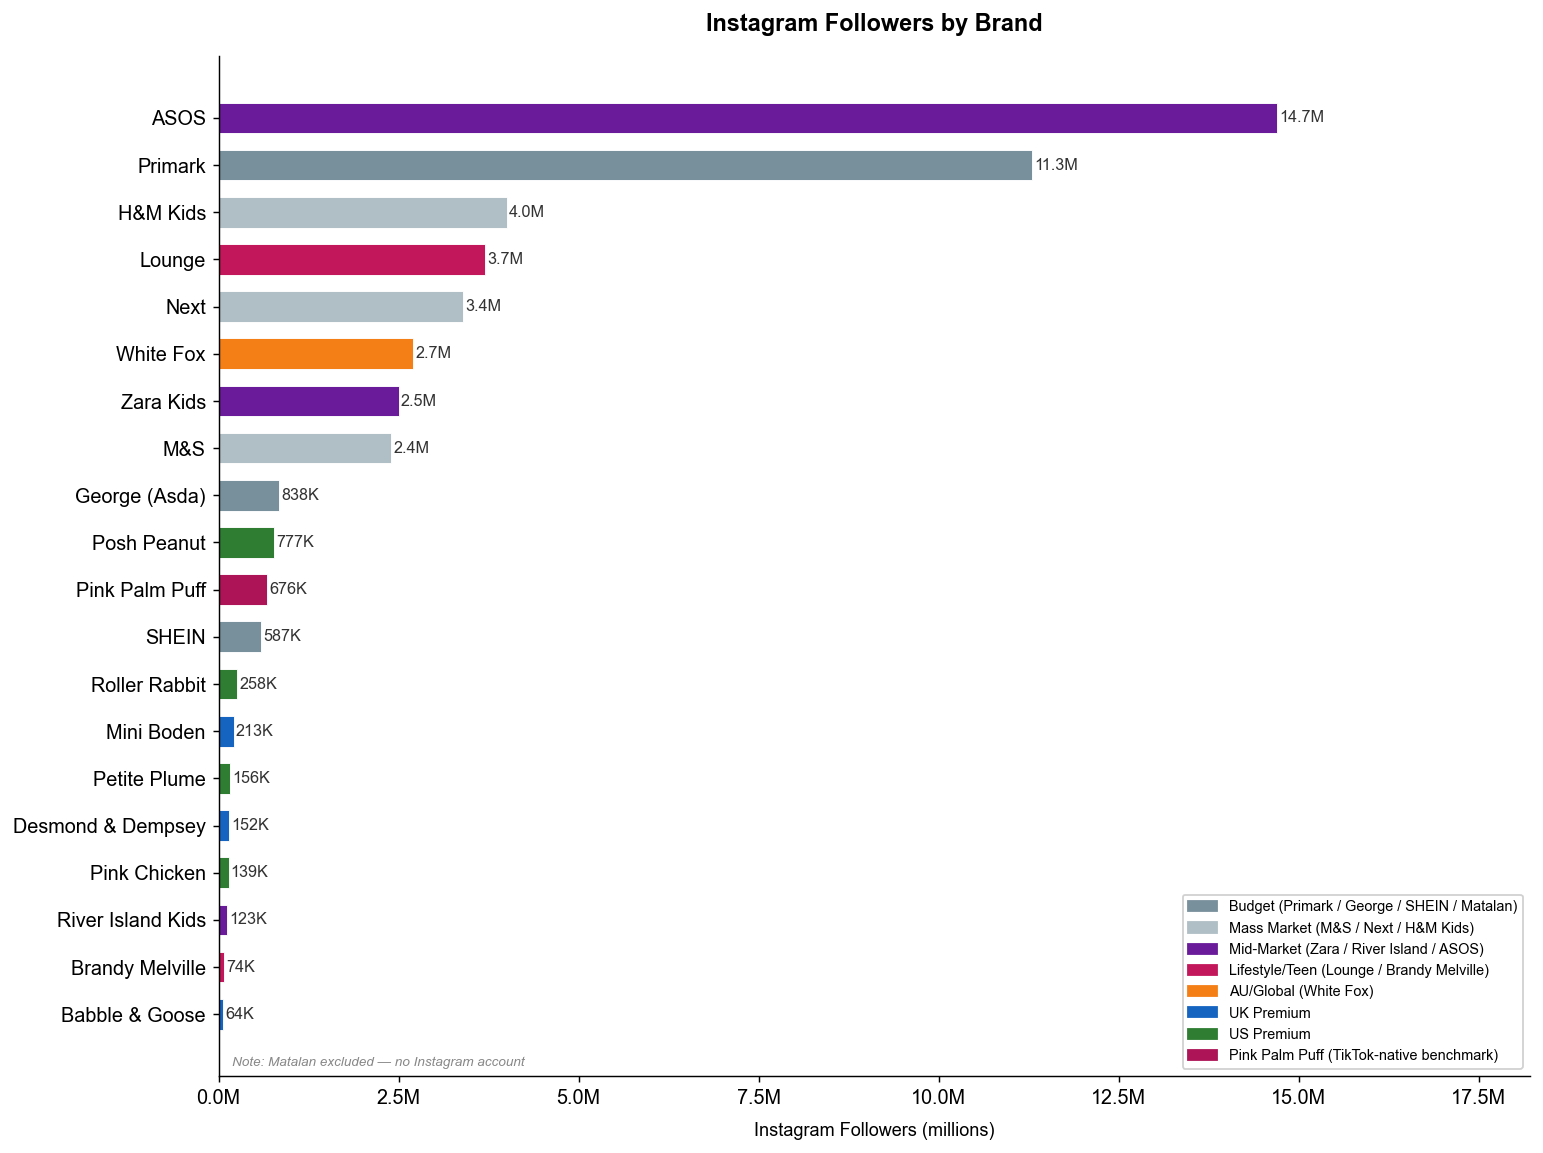

In [16]:
fig, ax = plt.subplots(figsize=(12, 9))

# Sort by IG followers descending; drop brands with no IG account
d = df.dropna(subset=['ig_followers']).sort_values('ig_followers', ascending=True)

bars = ax.barh(d['brand'], d['ig_followers'] / 1e6,
               color=d['colour'], edgecolor='white', linewidth=0.5, height=0.65)

# Value labels
for bar, val in zip(bars, d['ig_followers']):
    label = f'{val/1e6:.1f}M' if val >= 1e6 else f'{val/1e3:.0f}K'
    ax.text(bar.get_width() + 0.03, bar.get_y() + bar.get_height()/2,
            label, va='center', ha='left', fontsize=9, color='#333333')

ax.set_xlabel('Instagram Followers (millions)', labelpad=8)
ax.set_title('Instagram Followers by Brand', pad=14)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}M'))
ax.set_xlim(0, ax.get_xlim()[1] * 1.18)

# Legend — updated for new segments
legend_items = [
    mpatches.Patch(color=COLOURS['budget'],      label='Budget (Primark / George / SHEIN / Matalan)'),
    mpatches.Patch(color=COLOURS['mass'],        label='Mass Market (M&S / Next / H&M Kids)'),
    mpatches.Patch(color=COLOURS['mid_market'],  label='Mid-Market (Zara / River Island / ASOS)'),
    mpatches.Patch(color=COLOURS['lifestyle'],   label='Lifestyle/Teen (Lounge / Brandy Melville)'),
    mpatches.Patch(color=COLOURS['premium_au'],  label='AU/Global (White Fox)'),
    mpatches.Patch(color=COLOURS['premium_uk'],  label='UK Premium'),
    mpatches.Patch(color=COLOURS['premium_us'],  label='US Premium'),
    mpatches.Patch(color=COLOURS['ppp'],         label='Pink Palm Puff (TikTok-native benchmark)'),
]
ax.legend(handles=legend_items, loc='lower right', fontsize=8,
          framealpha=0.9, edgecolor='#cccccc')

# Note: Matalan excluded (no Instagram account)
ax.text(0.01, 0.01, 'Note: Matalan excluded — no Instagram account',
        transform=ax.transAxes, fontsize=7.5, color='#888888', style='italic')

plt.tight_layout()
plt.show()

### Chart Commentary — Instagram Followers by Brand

Mass market brands (M&S, Next, ASOS, H&M Kids, Zara Kids) dominate Instagram at scale, as expected — these are established retail giants with broad marketing budgets. But raw follower count is not the model for a new brand entering this space.

The more instructive signal here is the **lifestyle/identity tier**: Lounge and Brandy Melville have built audiences of 500K–1M+ not through mass-market spend, but through a clearly defined brand aesthetic and community. Neither is a kids brand. Neither competes on price. Both are proof that identity-first, DTC brands can build meaningful social scale.

**White Fox** is also instructive — explosive growth driven almost entirely by brand identity, TikTok-native content, and a tight aesthetic point of view. It does not serve the kids/teen segment, but the growth model is directly relevant.

**What this means for a new brand:** The goal at launch is not to compete with M&S's 2.4M followers. The goal is to build a brand identity tight enough, and content consistent enough, that followers earned are genuinely engaged. A new brand entering the 11–19 space with clear aesthetic positioning and platform-native content has a clear path — there is no established incumbent in that segment to displace.

---
## Chart 2 · Engagement Rate vs Instagram Followers
The inverse relationship between scale and engagement — smaller premium brands punch above their weight.
Brands with all likes hidden excluded (Mini Boden, Petite Plume, Pink Chicken).

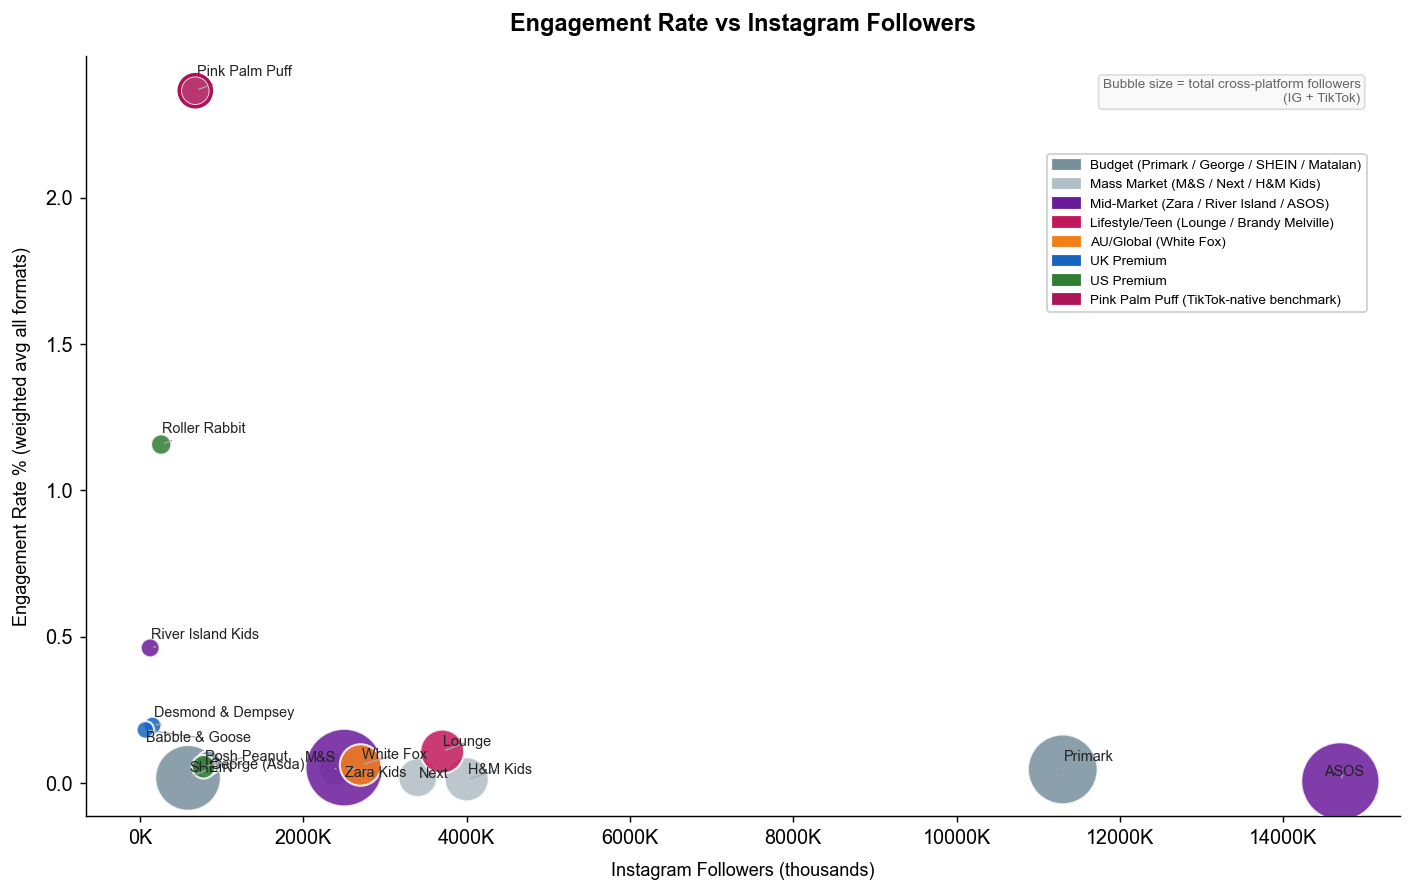

In [17]:
fig, ax = plt.subplots(figsize=(11, 7))

d = df.dropna(subset=['eng_rate', 'ig_followers'])

sizes = (d['total_followers'] / d['total_followers'].max() * 1800) + 80

scatter = ax.scatter(
    d['ig_followers'] / 1e3,
    d['eng_rate'],
    s=sizes,
    c=d['colour'],
    alpha=0.85,
    edgecolors='white',
    linewidths=1.2,
    zorder=3
)

offsets = {
    'Pink Palm Puff':    ( 15,   0.05),
    'Roller Rabbit':     ( 12,   0.04),
    'Babble & Goose':    ( 12,  -0.04),
    'Desmond & Dempsey': ( 12,   0.03),
    'Posh Peanut':       ( 15,   0.02),
    'White Fox':         ( 15,   0.02),
    'M&S':               (-380,  0.025),
    'Next':              ( 20,   0.0),
    'H&M Kids':          ( 12,   0.02),
    'Zara Kids':         ( 12,  -0.03),
    'River Island Kids': ( 12,   0.03),
    'ASOS':              (-200,  0.02),
    'Lounge':            ( 12,   0.02),
    'Brandy Melville':   ( 12,  -0.03),
    'SHEIN':             ( 12,   0.02),
    'Primark':           ( 12,   0.03),
    'George (Asda)':     ( 12,  -0.02),
}

for _, row in d.iterrows():
    ox, oy = offsets.get(row['brand'], (10, 0.02))
    ax.annotate(
        row['brand'],
        xy=(row['ig_followers']/1e3, row['eng_rate']),
        xytext=(row['ig_followers']/1e3 + ox, row['eng_rate'] + oy),
        fontsize=8,
        color='#222222',
        arrowprops=dict(arrowstyle='-', color='#aaaaaa', lw=0.7) if abs(ox) > 5 else None
    )

ppp_rows = d[d['brand'] == 'Pink Palm Puff']
if not ppp_rows.empty:
    ppp = ppp_rows.iloc[0]
    ppp_idx = ppp_rows.index[0]
    ax.scatter(ppp['ig_followers']/1e3, ppp['eng_rate'],
               s=float(sizes.loc[ppp_idx]) + 60,
               facecolors='none', edgecolors=COLOURS['ppp'], linewidths=2, zorder=4)

ax.set_xlabel('Instagram Followers (thousands)', labelpad=8)
ax.set_ylabel('Engagement Rate % (weighted avg all formats)', labelpad=8)
ax.set_title('Engagement Rate vs Instagram Followers', pad=14)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}K'))

ax.text(0.97, 0.97,
        'Bubble size = total cross-platform followers\n(IG + TikTok)',
        transform=ax.transAxes, ha='right', va='top',
        fontsize=7.5, color='#666666',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='#f9f9f9', edgecolor='#dddddd'))

ax.legend(handles=legend_items, fontsize=7.5, framealpha=0.9, edgecolor='#cccccc',
          loc='upper right', bbox_to_anchor=(0.98, 0.88))

plt.tight_layout()
plt.show()

### Chart Commentary — Engagement Rate vs Instagram Followers

This chart is the most strategically important in the dataset. It shows that **engagement rate and follower count are inversely correlated** — the bigger the brand, the less its audience interacts. This is the consistent pattern across every segment.

**Mass market brands** (M&S, Next, H&M Kids, ASOS) sit at the bottom right: large audiences, very low engagement. Their followers are passive. These brands reach people, but they don't build community.

**Identity-led and lifestyle brands** punch well above their weight. Pink Palm Puff leads the entire dataset at ~2.37% engagement — not because it spent more, but because its content is tightly aligned with its audience's identity. Roller Rabbit (~1.16%) and Babble & Goose follow a similar pattern. Desmond & Dempsey, despite a premium price point, outperforms every mass-market brand on engagement percentage.

**The implication for positioning:** A new brand does not need scale to be competitive. It needs engagement quality — content that resonates so strongly with a specific audience (in this case, 11–19 year olds with a defined aesthetic) that those followers are genuinely invested. Engagement is the signal that brand identity is working. At launch, a high engagement rate on a small but loyal audience is more valuable than a large passive one.

**Pink Palm Puff as benchmark:** 2.37% engagement at 676K followers is exceptional by any measure. The lesson is not the price point — it's the clarity of identity, the consistency of content format (all carousel), and the TikTok-native community-building approach.

---
## Chart 3 · Content Format Mix (Last 12 Posts)
The shift away from static content — virtually every premium brand is now Reels + Carousel only.

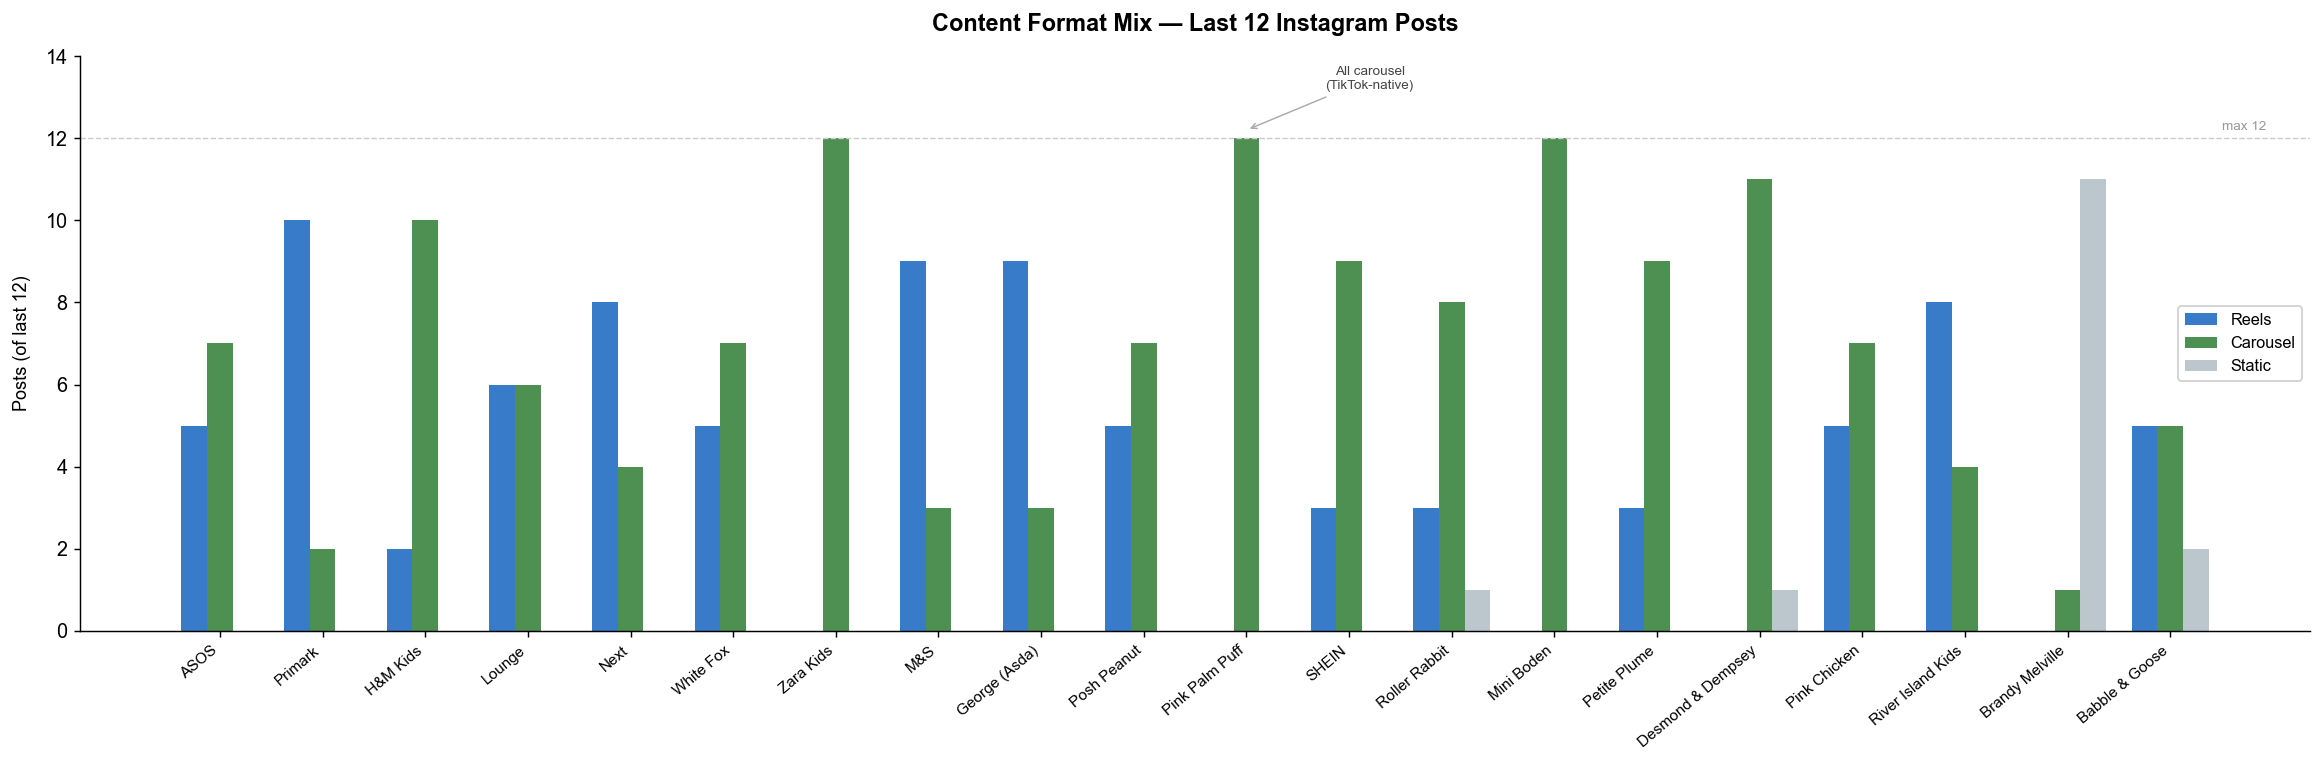

In [18]:
fig, ax = plt.subplots(figsize=(18, 6))

# Sort by IG followers descending; exclude Matalan (no IG)
d = df.dropna(subset=['ig_followers']).sort_values('ig_followers', ascending=False).copy()
brands = d['brand'].tolist()
x = np.arange(len(brands))
width = 0.25

b1 = ax.bar(x - width, d['reels'],    width, label='Reels',    color='#1565C0', alpha=0.85)
b2 = ax.bar(x,          d['carousel'], width, label='Carousel', color='#2E7D32', alpha=0.85)
b3 = ax.bar(x + width,  d['static'],  width, label='Static',   color='#B0BEC5', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(brands, rotation=40, ha='right', fontsize=8.5)
ax.set_ylabel('Posts (of last 12)', labelpad=8)
ax.set_title('Content Format Mix — Last 12 Instagram Posts', pad=14)
ax.set_ylim(0, 14)
ax.axhline(12, color='#cccccc', linewidth=0.8, linestyle='--')
ax.text(len(brands) - 0.5, 12.2, 'max 12', fontsize=7.5, color='#999999')
ax.legend(fontsize=9, framealpha=0.9, edgecolor='#cccccc')

# Annotate PPP if present
if 'Pink Palm Puff' in brands:
    idx = brands.index('Pink Palm Puff')
    ax.annotate('All carousel\n(TikTok-native)', xy=(idx, 12.2), xytext=(idx + 1.2, 13.2),
                fontsize=7.5, color='#444444', ha='center',
                arrowprops=dict(arrowstyle='->', color='#aaaaaa', lw=0.8))

plt.tight_layout()
plt.show()

### Chart Commentary — Content Format Mix

The format mix chart shows a clear split between how mass-market and identity-led brands approach Instagram content.

**Mass market brands** (M&S, Next, ASOS, H&M) lean on Reels for algorithmic reach and discovery. Reels are effective for impressions but typically generate lower save rates and shallower engagement than carousel — the format is built for views, not community.

**Identity and lifestyle brands** are almost exclusively carousel. Pink Palm Puff's all-carousel feed is not accidental — carousel is the format that best supports aesthetic-led storytelling: multiple images, a consistent visual language, swipe-through engagement. It generates more saves, more profile visits, and more follows from people genuinely interested in the brand world.

**Static images are effectively dead** across the entire dataset. No brand in 2026 is building an audience on single-image posts.

**For a brand built on aesthetic identity:** carousel is the primary content format. It allows product presentation, lifestyle context, and brand world-building in a single post. The content playbook is clear: consistent aesthetic, high-quality carousel on Instagram, paired with trend-native short-form video on TikTok. This is the model that PPP, Lounge, and Brandy Melville are all executing — just for different audiences.

---
## Chart 4 · Follower/Following Ratio — Brand Maturity Signal
A high ratio signals an established brand that earns followers organically. A low ratio suggests active follow-for-follow growth tactics.

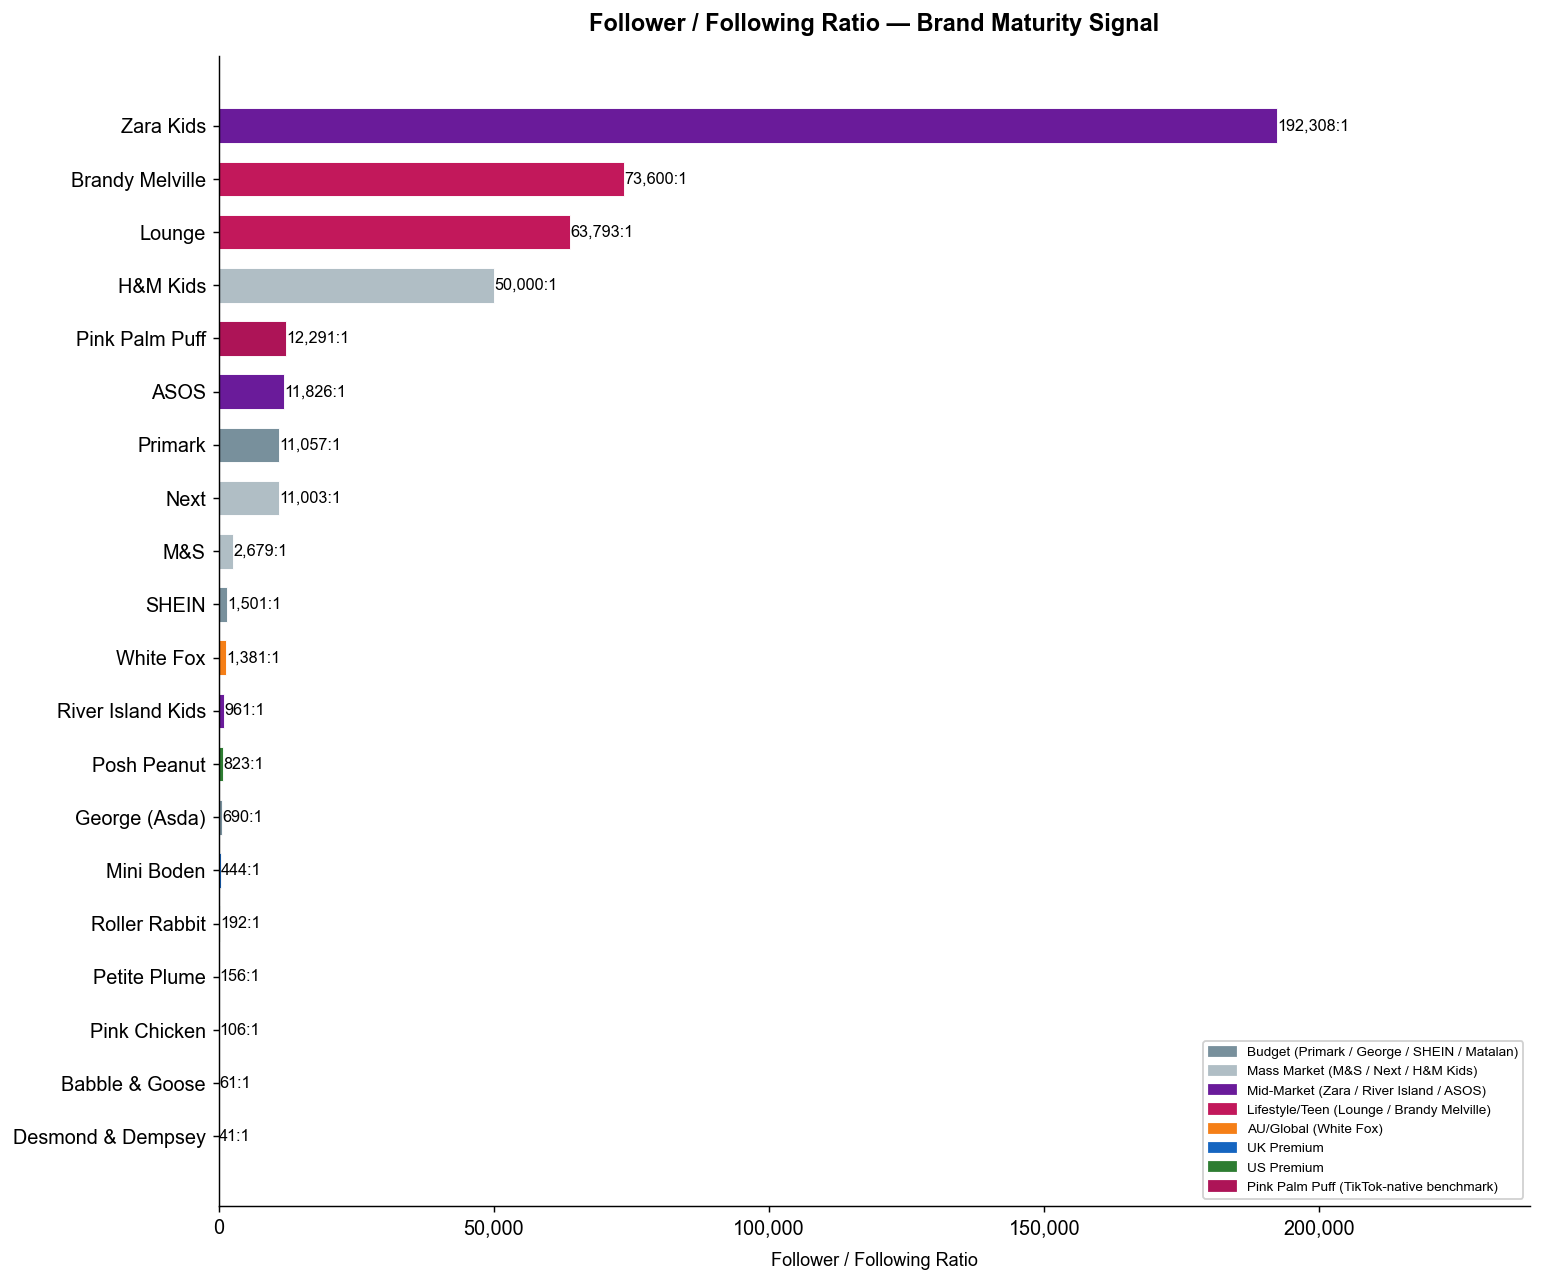

In [19]:
fig, ax = plt.subplots(figsize=(12, 10))

# Exclude brands with no IG (Matalan) and no ratio data
d = df.dropna(subset=['ratio']).sort_values('ratio', ascending=True).copy()

bars = ax.barh(d['brand'], d['ratio'],
               color=d['colour'], edgecolor='white', linewidth=0.5, height=0.65)

for bar, val in zip(bars, d['ratio']):
    ax.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
            f'{val:,.0f}:1', va='center', ha='left', fontsize=9)

ax.set_xlabel('Follower / Following Ratio', labelpad=8)
ax.set_title('Follower / Following Ratio — Brand Maturity Signal', pad=14)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.set_xlim(0, ax.get_xlim()[1] * 1.18)

ax.legend(handles=legend_items, fontsize=7.5, framealpha=0.9,
          edgecolor='#cccccc', loc='lower right')

plt.tight_layout()
plt.show()

### Chart Commentary — Follower / Following Ratio

The follower/following ratio is a brand maturity signal. A high ratio means a brand earns followers organically — people find it and follow it without the brand needing to reciprocate. A low ratio often indicates early-stage growth tactics (follow-for-follow) or influencer outreach-heavy strategies.

**Mass market brands** (M&S, Next, H&M, ASOS) sit at the top through legacy and scale — they have millions of followers and follow almost nobody. This is expected for established retail brands.

**Pink Palm Puff's ratio (~12,291:1)** is the most significant data point for a new brand. It has achieved an elite ratio despite being relatively young. This signals that its audience growth is genuinely organic — earned through content quality and brand identity, not growth hacking. It is in the same tier as mass retailers but built through a completely different model.

**For a new brand, the ratio matters from day one.** Following thousands of accounts to get follows back is a short-term tactic that signals low brand confidence and dilutes the account's perceived authority. The goal is to build content compelling enough that the ratio stays high from the start — even at small absolute numbers. A brand with 5,000 followers and a 100:1 ratio has a stronger foundation than one with 10,000 followers and a 2:1 ratio.

---
### Instagram → TikTok

Charts 1–4 examined Instagram: follower scale, engagement quality, content format, and brand maturity. The next three charts shift to TikTok and cross-platform reach — where the competitive landscape looks very different.

---
## Chart 5 · TikTok vs Instagram Followers — Platform Balance
Where do brands live? Most premium brands are Instagram-dominant. Pink Palm Puff is the outlier — TikTok is clearly the primary platform.

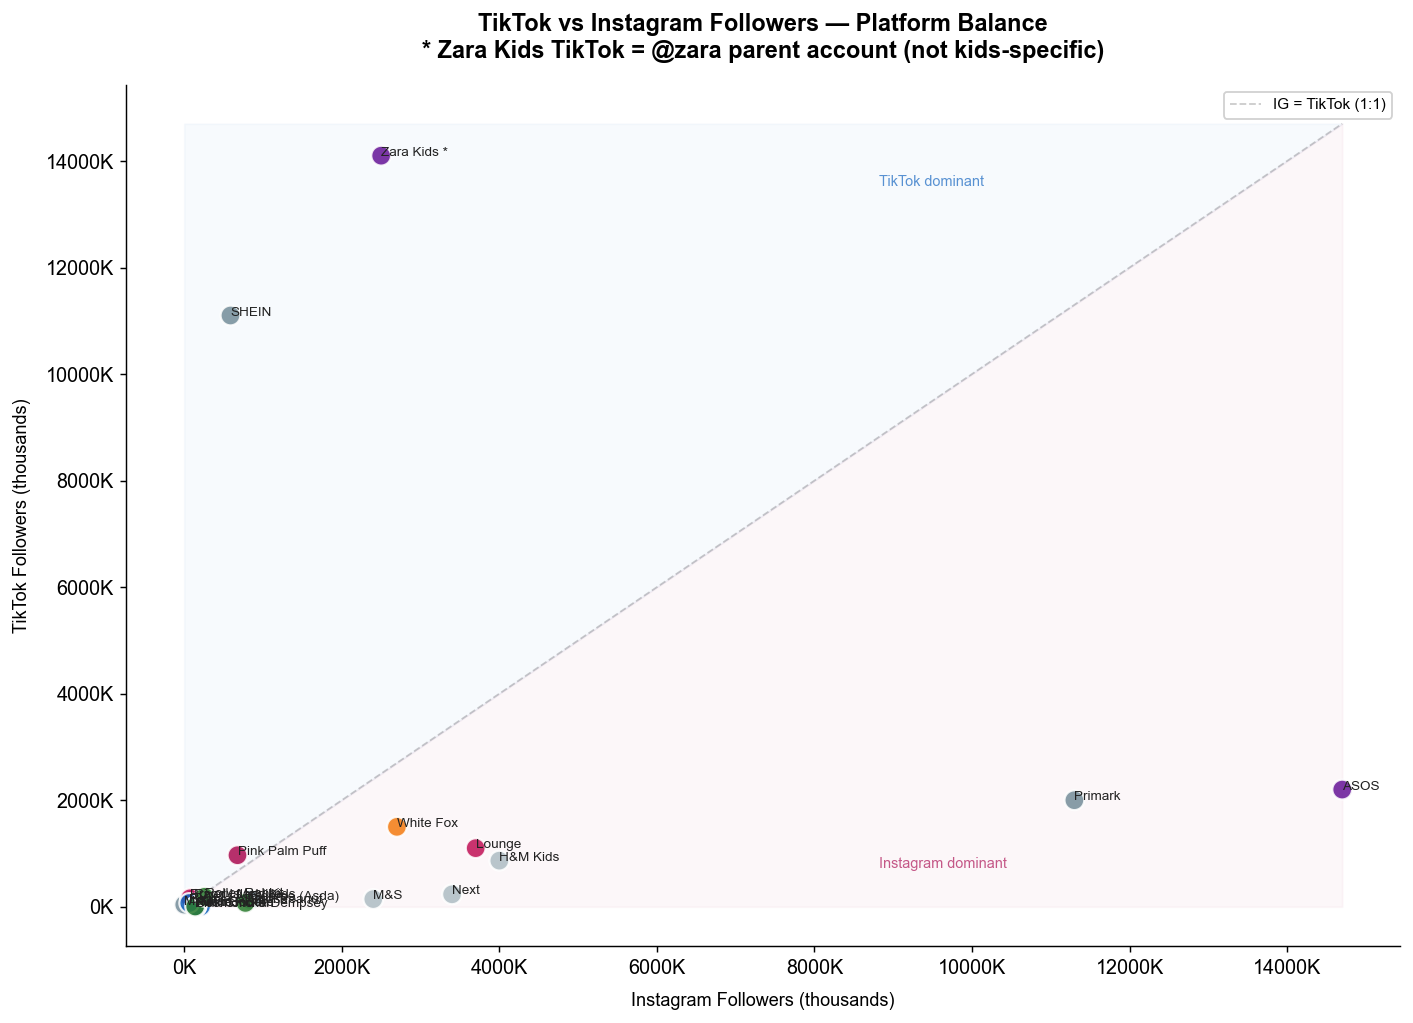

In [20]:
fig, ax = plt.subplots(figsize=(11, 8))

d = df.copy()
d['display_brand'] = d['brand'].replace({'Zara Kids': 'Zara Kids *'})

ax.scatter(
    d['ig_followers'].fillna(0) / 1e3,
    d['tt_followers'].fillna(0) / 1e3,
    s=120,
    c=d['colour'],
    alpha=0.88,
    edgecolors='white',
    linewidths=1.2,
    zorder=3
)

max_val = max(d['ig_followers'].fillna(0).max(), d['tt_followers'].fillna(0).max()) / 1e3
ax.plot([0, max_val], [0, max_val], '--', color='#cccccc', linewidth=1, zorder=1, label='IG = TikTok (1:1)')
ax.fill_between([0, max_val], [0, max_val], max_val, alpha=0.03, color='#1565C0')
ax.fill_between([0, max_val], 0, [0, max_val], alpha=0.03, color='#AD1457')

ax.text(max_val * 0.6, max_val * 0.92, 'TikTok dominant', fontsize=8, color='#1565C0', alpha=0.7)
ax.text(max_val * 0.6, max_val * 0.05, 'Instagram dominant', fontsize=8, color='#AD1457', alpha=0.7)

label_offsets = {
    'Pink Palm Puff':    ( 20,  20),
    'White Fox':         ( 20,  20),
    'M&S':               (-280, 20),
    'Next':              ( 20, -40),
    'Posh Peanut':       ( 20,  15),
    'Roller Rabbit':     ( 20,  15),
    'Babble & Goose':    ( 20, -30),
    'Mini Boden':        ( 20,  15),
    'Petite Plume':      ( 20, -30),
    'Desmond & Dempsey': (-290, 15),
    'Pink Chicken':      ( 20,  15),
    'H&M Kids':          ( 20,  15),
    'Zara Kids':         ( 20, -25),
    'River Island Kids': ( 20,  15),
    'ASOS':              (-200, 15),
    'Lounge':            ( 20,  15),
    'Brandy Melville':   ( 20, -25),
    'SHEIN':             ( 20,  15),
    'Primark':           ( 20,  20),
    'George (Asda)':     ( 20, -25),
    'Matalan':           ( 20,  15),
}

for _, row in d.iterrows():
    ig_val = (row['ig_followers'] if pd.notna(row['ig_followers']) else 0) / 1e3
    tt_val = (row['tt_followers'] if pd.notna(row['tt_followers']) else 0) / 1e3
    ox, oy = label_offsets.get(row['brand'], (15, 15))
    ax.annotate(
        row['display_brand'],
        xy=(ig_val, tt_val),
        xytext=(ig_val + ox / 40, tt_val + oy / 40),
        fontsize=7.5,
        color='#222222'
    )

ax.set_xlabel('Instagram Followers (thousands)', labelpad=8)
ax.set_ylabel('TikTok Followers (thousands)', labelpad=8)
ax.set_title('TikTok vs Instagram Followers — Platform Balance\n'
             '* Zara Kids TikTok = @zara parent account (not kids-specific)',
             fontsize=13, fontweight='bold', pad=15)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}K'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}K'))

ax.legend(fontsize=8.5, framealpha=0.9, edgecolor='#cccccc')

plt.tight_layout()
plt.show()

### Chart 5b · TikTok vs Instagram — Zoomed View (Excluding Outliers)
Same data as above, excluding ASOS, H&M Kids, Primark, SHEIN, and Zara Kids to show the smaller brand cluster clearly.

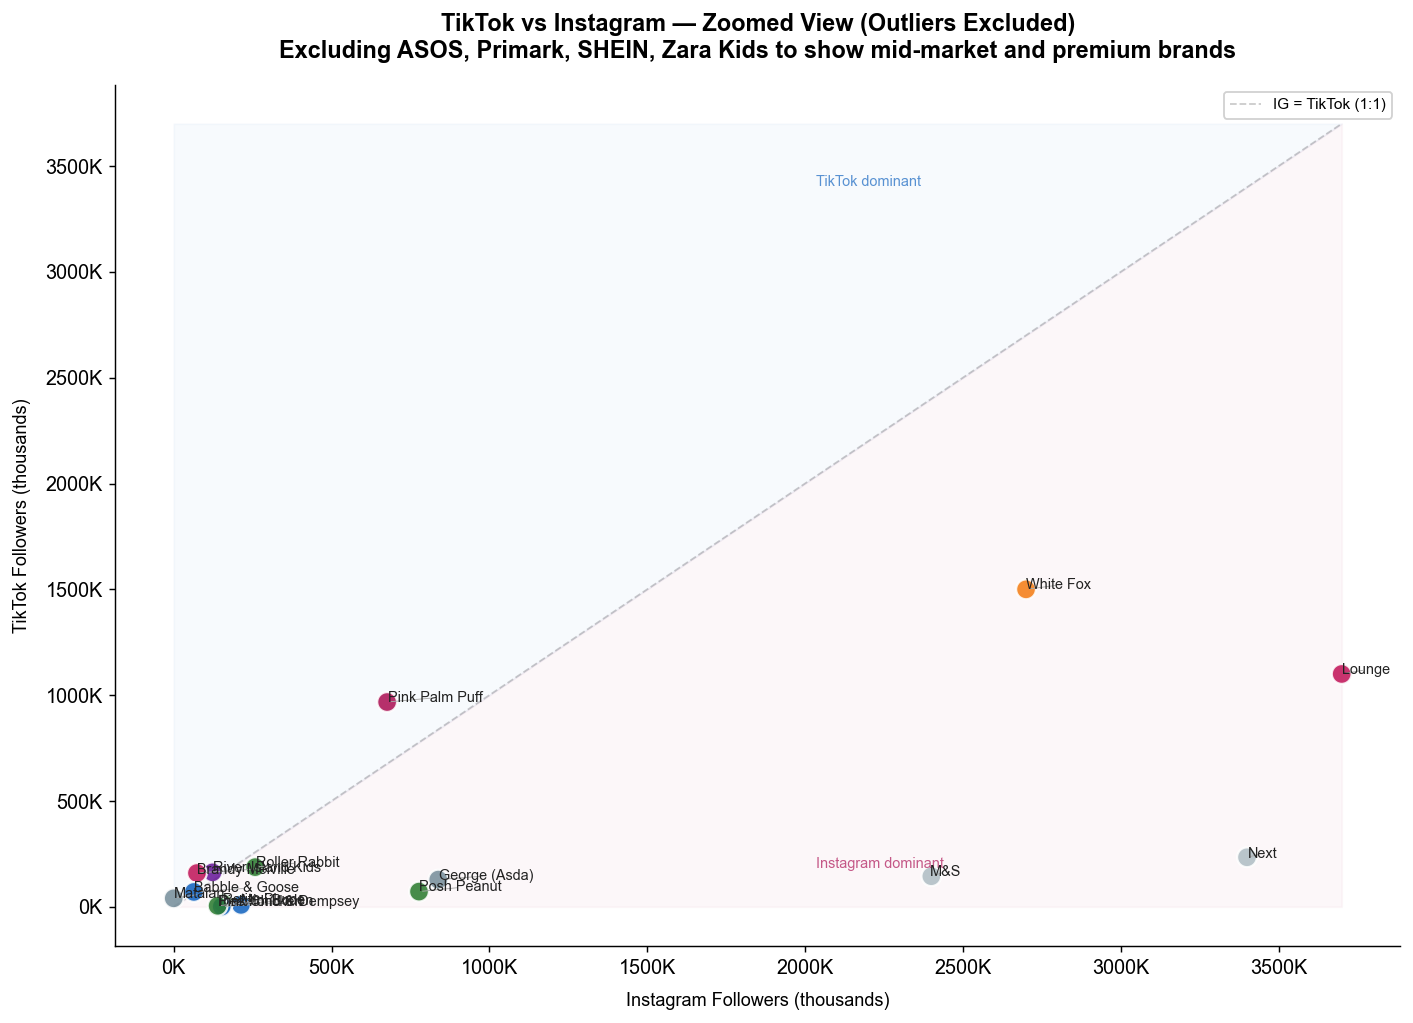

In [21]:
fig, ax = plt.subplots(figsize=(11, 8))

# Exclude large outliers to zoom into the smaller brand cluster
exclude = ['Zara Kids', 'ASOS', 'Primark', 'SHEIN', 'H&M Kids']
d = df[~df['brand'].isin(exclude)].copy()

ax.scatter(
    d['ig_followers'].fillna(0) / 1e3,
    d['tt_followers'].fillna(0) / 1e3,
    s=120,
    c=d['colour'],
    alpha=0.88,
    edgecolors='white',
    linewidths=1.2,
    zorder=3
)

max_val = max(d['ig_followers'].fillna(0).max(), d['tt_followers'].fillna(0).max()) / 1e3
ax.plot([0, max_val], [0, max_val], '--', color='#cccccc', linewidth=1, zorder=1, label='IG = TikTok (1:1)')
ax.fill_between([0, max_val], [0, max_val], max_val, alpha=0.03, color='#1565C0')
ax.fill_between([0, max_val], 0, [0, max_val], alpha=0.03, color='#AD1457')

ax.text(max_val * 0.55, max_val * 0.92, 'TikTok dominant', fontsize=8, color='#1565C0', alpha=0.7)
ax.text(max_val * 0.55, max_val * 0.05, 'Instagram dominant', fontsize=8, color='#AD1457', alpha=0.7)

label_offsets = {
    'Pink Palm Puff':    ( 25,  25),
    'White Fox':         ( 25,  25),
    'M&S':               (-120, 25),
    'Next':              ( 25, -40),
    'Posh Peanut':       ( 25,  20),
    'Roller Rabbit':     ( 25,  20),
    'Babble & Goose':    ( 25, -35),
    'Mini Boden':        ( 25,  20),
    'Petite Plume':      ( 25, -35),
    'Desmond & Dempsey': (-160, 20),
    'Pink Chicken':      ( 25,  20),
    'River Island Kids': ( 25,  20),
    'Lounge':            ( 25,  20),
    'Brandy Melville':   ( 25, -35),
    'George (Asda)':     ( 25, -30),
    'Matalan':           ( 25,  20),
}

for _, row in d.iterrows():
    ig_val = (row['ig_followers'] if pd.notna(row['ig_followers']) else 0) / 1e3
    tt_val = (row['tt_followers'] if pd.notna(row['tt_followers']) else 0) / 1e3
    ox, oy = label_offsets.get(row['brand'], (20, 20))
    ax.annotate(
        row['brand'],
        xy=(ig_val, tt_val),
        xytext=(ig_val + ox / 20, tt_val + oy / 20),
        fontsize=8,
        color='#222222',
        arrowprops=dict(arrowstyle='-', color='#aaaaaa', lw=0.5) if abs(ox) > 20 else None
    )

ax.set_xlabel('Instagram Followers (thousands)', labelpad=8)
ax.set_ylabel('TikTok Followers (thousands)', labelpad=8)
ax.set_title('TikTok vs Instagram — Zoomed View (Outliers Excluded)\n'
             'Excluding ASOS, Primark, SHEIN, Zara Kids to show mid-market and premium brands',
             fontsize=13, fontweight='bold', pad=15)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}K'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}K'))

ax.legend(fontsize=8.5, framealpha=0.9, edgecolor='#cccccc')

plt.tight_layout()
plt.show()

### Chart Commentary — TikTok vs Instagram Platform Balance

**Data note:** Zara Kids* TikTok data is the @zara parent account, which covers all Zara divisions (womenswear, menswear, kids, home). The follower count (~14M) reflects the full brand, not a kids-only presence, and significantly overstates Zara Kids' actual TikTok reach. This data point should be treated as a data caveat rather than a benchmark.

The most important pattern in this chart is how far below the 1:1 diagonal line most UK brands sit. **Instagram-dominant, TikTok-absent** is the default state for the vast majority of brands in this dataset — including brands that have strong visual identities (River Island Kids, Brandy Melville, Mini Boden). They have not translated their brand to TikTok at meaningful scale.

**White Fox and Pink Palm Puff are the outliers.** Both sit at or above the diagonal — they have built genuine TikTok presence alongside (or ahead of) Instagram. White Fox has the largest combined audience in the dataset. PPP has a TikTok-first model where short-form video is the primary growth engine and Instagram is the conversion and community layer.

**The zoomed view (Chart 5b)** makes the premium brand cluster visible: identity-led brands such as Roller Rabbit, Brandy Melville, and Babble & Goose are heavily Instagram-skewed with minimal TikTok investment — unlike Pink Palm Puff, which built its audience TikTok-first.

**The opportunity for a new brand:** Every brand currently serving the teen/young adult space — Brandy Melville, Lounge, River Island Kids — is IG-heavy and TikTok-underweight. A new brand built TikTok-first, with a consistent aesthetic and teen-relevant content, would face almost no established competition on the platform in the kids/teen nightwear and loungewear space.

---
## Chart 6 · TikTok Average Video Views
Views per video reveal content resonance independent of follower count — the real measure of TikTok reach.

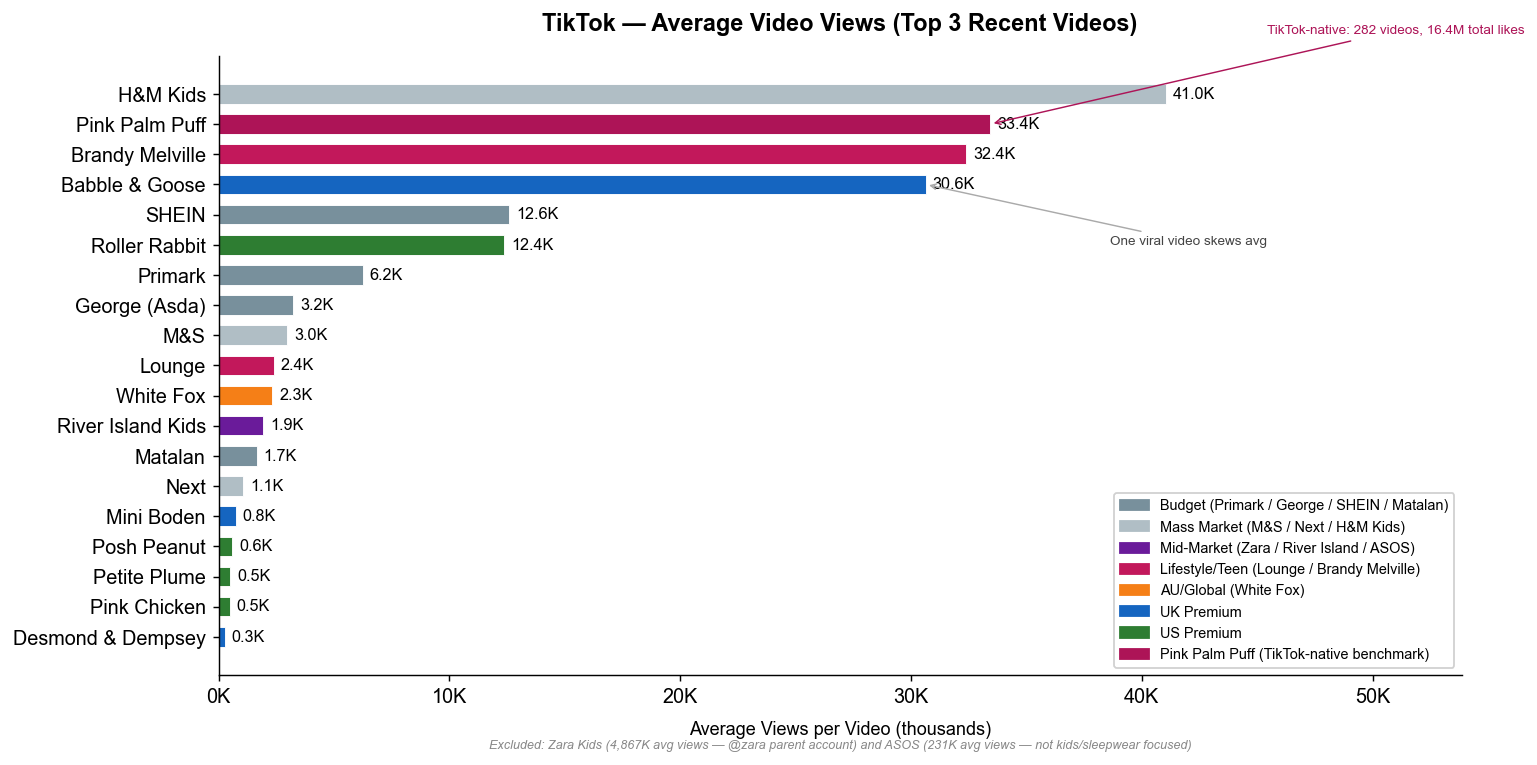

In [22]:
fig, ax = plt.subplots(figsize=(12, 6))

# Exclude Zara Kids and ASOS — both distort the scale.
# Zara Kids: @zara parent account, not attributable to kids content.
# ASOS: 231K avg views driven by viral fashion content, not kids/sleepwear.
d = df[~df['brand'].isin(['Zara Kids', 'ASOS'])].sort_values('tt_avg_views', ascending=True).copy()

bars = ax.barh(d['brand'], d['tt_avg_views'] / 1e3,
               color=d['colour'], edgecolor='white', linewidth=0.5, height=0.65)

for bar, val in zip(bars, d['tt_avg_views']):
    label = f'{val/1e3:.1f}K'
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            label, va='center', ha='left', fontsize=9)

ax.set_xlabel('Average Views per Video (thousands)', labelpad=8)
ax.set_title('TikTok — Average Video Views (Top 3 Recent Videos)', pad=14)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}K'))
ax.set_xlim(0, ax.get_xlim()[1] * 1.25)

# Annotations — positioned to avoid overlap
brand_positions = {row['brand']: idx for idx, (_, row) in enumerate(d.iterrows())}

if 'Babble & Goose' in brand_positions:
    bg_row = d[d['brand'] == 'Babble & Goose'].iloc[0]
    bg_y = brand_positions['Babble & Goose']
    ax.annotate('One viral video skews avg',
                xy=(bg_row['tt_avg_views']/1e3, bg_y),
                xytext=(bg_row['tt_avg_views']/1e3 + 8, bg_y - 2),
                fontsize=7.5, color='#444444',
                arrowprops=dict(arrowstyle='->', color='#aaaaaa', lw=0.8))

if 'Pink Palm Puff' in brand_positions:
    ppp_row = d[d['brand'] == 'Pink Palm Puff'].iloc[0]
    ppp_y = brand_positions['Pink Palm Puff']
    ax.annotate('TikTok-native: 282 videos, 16.4M total likes',
                xy=(ppp_row['tt_avg_views']/1e3, ppp_y),
                xytext=(ppp_row['tt_avg_views']/1e3 + 12, ppp_y + 3),
                fontsize=7.5, color=COLOURS['ppp'],
                arrowprops=dict(arrowstyle='->', color=COLOURS['ppp'], lw=0.8))

ax.text(0.5, -0.12,
        'Excluded: Zara Kids (4,867K avg views — @zara parent account) and ASOS (231K avg views — not kids/sleepwear focused)',
        transform=ax.transAxes, fontsize=7, color='#888888', style='italic', ha='center')

ax.legend(handles=legend_items, fontsize=8, framealpha=0.9,
          edgecolor='#cccccc', loc='lower right')

plt.tight_layout()
plt.show()

### Chart Commentary — TikTok Average Video Views

**Data note:** Zara Kids* TikTok views are drawn from the @zara parent account and are not attributable to kids content. They are included for completeness but should not be read as representative of a kids/teen-focused TikTok strategy.

The views-per-video chart is the clearest illustration of the TikTok gap in this category. Most brands in the dataset — including those with strong brand identities — are generating sub-5K average views per video. At that level, they are effectively invisible on the platform. TikTok's algorithm does not reward frequency or brand name recognition; it rewards content that earns views from cold audiences.

**Pink Palm Puff stands apart.** Its average views, combined with 16.4M total profile likes across 282 videos, confirm a flywheel that most brands in this dataset have not achieved: consistent content output → algorithmic amplification → growing follower base → higher baseline views per video. This is a compounding effect, not a one-off viral moment.

**Babble & Goose** is an instructive contrast: one viral video inflates the average, but without volume and consistency behind it, the effect doesn't compound. Viral moments without a content system don't build lasting TikTok presence.

**For a new brand:** TikTok in the kids/teen nightwear and loungewear category is wide open. The brands that should own it — those serving teens, with a defined aesthetic — mostly don't have meaningful TikTok presence. A consistent, trend-native posting cadence with a clear visual identity is the entry point. The bar is low because incumbents have not cleared it.

---
## Chart 7 · Cross-Platform Summary — Total Reach
Stacked view of IG + TikTok combined reach per brand.

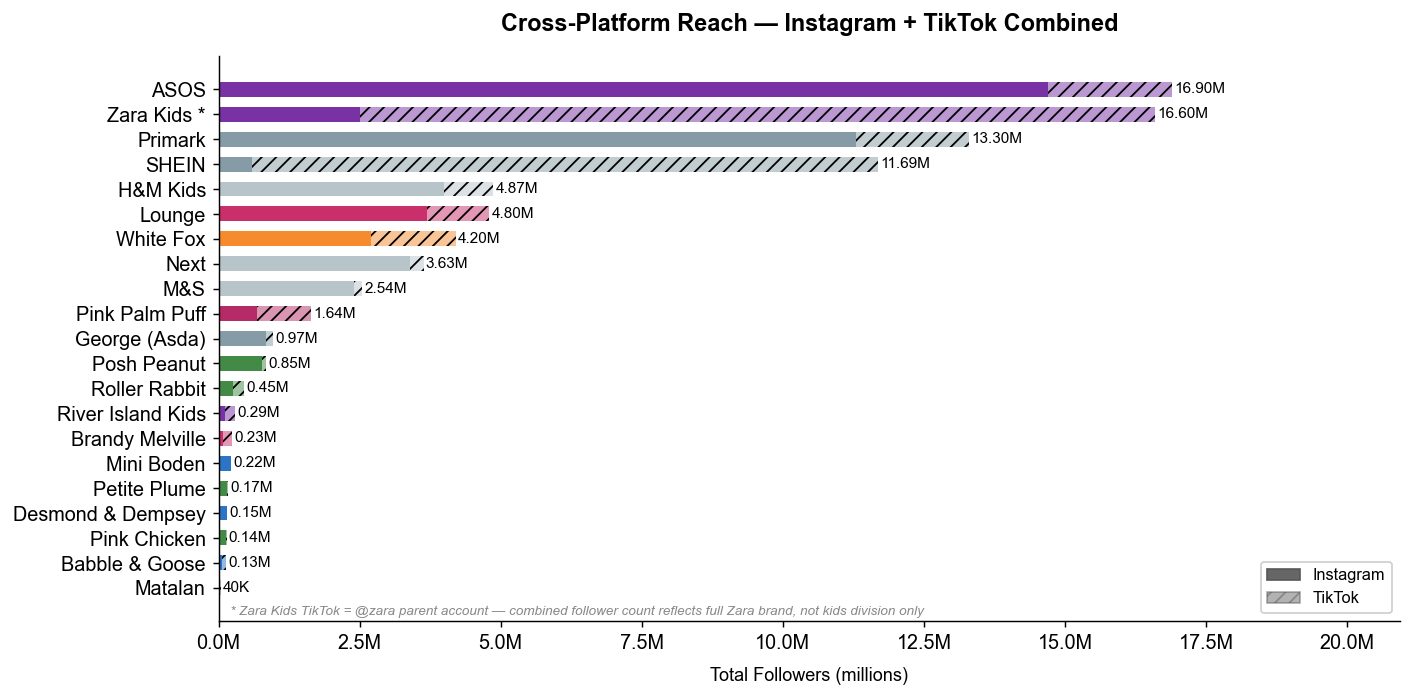

In [23]:
fig, ax = plt.subplots(figsize=(11, 5.5))

d = df.sort_values('total_followers', ascending=True).copy()
# Display Zara Kids as parent account in TikTok charts
d['display_brand'] = d['brand'].replace({'Zara Kids': 'Zara Kids *'})

ig_vals = d['ig_followers'].fillna(0) / 1e6
tt_vals = d['tt_followers'].fillna(0) / 1e6

bars1 = ax.barh(d['display_brand'], ig_vals, height=0.6,
                color=d['colour'], alpha=0.9, label='Instagram')
bars2 = ax.barh(d['display_brand'], tt_vals, height=0.6, left=ig_vals,
                color=d['colour'], alpha=0.45, hatch='///', label='TikTok')

for _, row in d.iterrows():
    total = (row['ig_followers'] + row['tt_followers']) / 1e6 if pd.notna(row['ig_followers']) and pd.notna(row['tt_followers']) else \
            (row['ig_followers'] / 1e6 if pd.notna(row['ig_followers']) else row['tt_followers'] / 1e6 if pd.notna(row['tt_followers']) else 0)
    label = f'{total:.2f}M' if total >= 0.1 else f'{total*1000:.0f}K'
    ax.text(total + 0.04, list(d['display_brand']).index(row['display_brand']),
            label, va='center', ha='left', fontsize=8.5)

ax.set_xlabel('Total Followers (millions)', labelpad=8)
ax.set_title('Cross-Platform Reach — Instagram + TikTok Combined', pad=14)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}M'))
ax.set_xlim(0, ax.get_xlim()[1] * 1.18)

ig_patch = mpatches.Patch(color='#555555', alpha=0.9, label='Instagram')
tt_patch = mpatches.Patch(color='#555555', alpha=0.45, hatch='///', label='TikTok')
ax.legend(handles=[ig_patch, tt_patch], fontsize=9,
          framealpha=0.9, edgecolor='#cccccc', loc='lower right')

ax.text(0.01, 0.01,
        '* Zara Kids TikTok = @zara parent account — combined follower count reflects full Zara brand, not kids division only',
        transform=ax.transAxes, fontsize=7.5, color='#888888', style='italic')

plt.tight_layout()
plt.show()

### Chart Commentary — Cross-Platform Reach

**Data note:** Zara Kids* combined reach includes @zara parent account TikTok followers (~14M), which covers all Zara brand divisions. Zara Kids' true cross-platform reach is significantly lower than shown.

The combined reach chart shows the full audience landscape. White Fox leads through genuine cross-platform scale — a large IG audience and one of the strongest TikTok presences in the dataset for this category. Mass-market brands (M&S, Next, ASOS) dominate on Instagram volume but have minimal TikTok contribution to their combined total.

**Pink Palm Puff** is the strategic reference point: its combined reach (~1.64M) is meaningfully large for a brand of its age and positioning, and the majority of it comes from TikTok. This matters because TikTok followers are typically more actively engaged and more likely to discover new content — they are not just passive follow-backs.

**The landscape gap for a new brand:** No brand in this dataset is building cross-platform reach specifically for the 11–19 UK market with a focused aesthetic identity. The brands with the largest combined audiences either serve adults (White Fox, M&S, Next) or stop at age 14 (H&M Kids, Zara Kids, River Island Kids). The teen segment — 11 to 19 — is uncontested from a social-first, brand-identity perspective. A new brand that builds TikTok-first and converts to Instagram community can grow into meaningful combined reach in this space without displacing any incumbent.

---
## Key Findings

In [24]:
print('=' * 70)
print('KEY FINDINGS — Social Media Analysis')
print('=' * 70)

print()
print('1. SCALE LANDSCAPE: Mass market dominates follower volume.')
print('   M&S, Next, ASOS, H&M, Zara, Primark hold the largest audiences.')
print('   Independent/lifestyle brands (Lounge, Brandy Melville) show')
print('   meaningful scale can be built on identity alone at mid-market prices.')

print()
print('2. ENGAGEMENT INVERSE: Smaller brands punch above their weight.')
d_eng = df.dropna(subset=['eng_rate']).sort_values('eng_rate', ascending=False)
for _, row in d_eng.iterrows():
    print(f'   {row["brand"]:<22} {row["ig_followers"]/1e3 if pd.notna(row["ig_followers"]) else 0:>7.0f}K followers '
          f'eng rate: {row["eng_rate"]:>6.3f}%')

print()
print('3. CONTENT FORMAT: Static posts essentially dead across all brands.')
print('   Carousel dominant for premium/lifestyle brands (storytelling, depth).')
print('   Reels used by mass brands for algorithmic reach/discovery.')

print()
print('4. TIKTOK DIVIDE:')
print('   Budget/mass UK brands have TikTok presence but low engagement velocity.')
print('   Mid-market and lifestyle brands vary widely:')
for _, row in df.sort_values('tt_followers').iterrows():
    tt = row['tt_followers'] if pd.notna(row['tt_followers']) else 0
    ig = row['ig_followers'] if pd.notna(row['ig_followers']) else 0
    print(f'   {row["brand"]:<22} TikTok: {tt/1e3:>7.1f}K  IG: {ig/1e3:>7.1f}K')

print()
print('5. PINK PALM PUFF — BENCHMARK CASE STUDY:')
ppp = df[df['brand'] == 'Pink Palm Puff']
if not ppp.empty:
    ppp = ppp.iloc[0]
    print(f'   TikTok: {ppp["tt_followers"]/1e3:.0f}K followers | IG: {ppp["ig_followers"]/1e3:.0f}K followers')
    print(f'   Engagement rate: {ppp["eng_rate"]:.3f}% — highest in dataset')
    print(f'   Follower/following ratio: {ppp["ratio"]:,.0f}:1 — strong organic earned growth')
    print(f'   All-carousel IG. TikTok-native founder-as-influencer model.')
    print(f'   IMPLICATION: Demonstrates that strong brand identity + TikTok-native')
    print(f'   content strategy can build a highly engaged audience in teen apparel.')
    print(f'   The model is platform-first, not price-point dependent.')

print()
print('=' * 70)


KEY FINDINGS — Social Media Analysis

1. SCALE LANDSCAPE: Mass market dominates follower volume.
   M&S, Next, ASOS, H&M, Zara, Primark hold the largest audiences.
   Independent/lifestyle brands (Lounge, Brandy Melville) show
   meaningful scale can be built on identity alone at mid-market prices.

2. ENGAGEMENT INVERSE: Smaller brands punch above their weight.
   Pink Palm Puff             676K followers eng rate:  2.366%
   Roller Rabbit              258K followers eng rate:  1.157%
   River Island Kids          123K followers eng rate:  0.462%
   Desmond & Dempsey          152K followers eng rate:  0.197%
   Babble & Goose              64K followers eng rate:  0.182%
   Lounge                    3700K followers eng rate:  0.108%
   George (Asda)              838K followers eng rate:  0.069%
   White Fox                 2700K followers eng rate:  0.062%
   Posh Peanut                777K followers eng rate:  0.056%
   Zara Kids                 2500K followers eng rate:  0.053%
   M&

---

### Adjacent Brands (Not in Dataset)

Not included in the 21-brand social analysis but worth noting as adjacent players:
- **Pull & Bear** — teen fast fashion, includes loungewear but no premium positioning or distinct sleepwear identity
- **Skinnydip London** — teen-coded nightwear (£22–38), playful/character-driven aesthetic, collab-heavy
- **Adanola** - UK premium DTC activewear/nightwear, social-first model
- **Nobody's Child** - UK sustainable premium, shows ethical appetite
- **Ava & Bear London** - UK premium kids sleepwear, stops at ~age 10
- **Hanna Andersson** — US premium kids sleepwear brand, strong in matching family pyjamas (a rising search trend identified in notebook 02). No UK presence, but validates that premium kids sleepwear at scale is an established category in the US market

None of these brands occupies the identity-led premium teen space identified in notebook 01. Pull & Bear and Skinnydip are explored further in notebook 04 (Strategic Context).